In [126]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy.stats import beta


# import your class
# from your_module import ExponentialBet


# ----------------------------
# 1. DATA GENERATION
# ----------------------------

def generate_data(n=5000, d=5, rho=0.6, beta_strength=2.0, noise=1.0, seed=0):
    np.random.seed(seed)

    Sigma = rho * np.ones((d, d)) + (1 - rho) * np.eye(d)

    X = np.random.multivariate_normal(np.zeros(d), Sigma, size=n)

    j = 0

    beta_ = np.zeros(d)
    beta_[j] = beta_strength

    gamma = np.ones(d)
    gamma[1] = 0.0

    eps = noise * np.random.randn(n)

    Y = X @ beta_ + X @ gamma + eps

    return X, Y, Sigma, j


def generate_data_noise(n=5000, d=5, rho=0.6, beta_strength=2.0, seed=0, noise = 1.0):
    np.random.seed(seed)

    Sigma = rho * np.ones((d, d)) + (1 - rho) * np.eye(d)

    X = np.random.multivariate_normal(np.zeros(d), Sigma, size=n)

    j = 0

    beta_ = np.zeros(d)
    beta_[j] = beta_strength

    gamma = np.zeros(d)
    gamma[1] = 0.0

    eps = noise * (beta.rvs(0.1, 0.1, size = n) - 0.5)

    Y = X @ beta_ + X @ gamma + eps

    return X, Y, Sigma, j



# ----------------------------
# 3. SETUP DATA
# ----------------------------

X, Y, Sigma, j = generate_data(n=500, beta_strength=0.01)


In [72]:
from ML_e_process import ML_e_process
from sklearn.linear_model import LassoCV

from ExponentialBet import ExponentialBet  
from AntisymmetricBet import AntisymmetricBet  # adjust import
from utils import prepare_exponential_parameters, prepare_coin_betting_parameters, g_family_cb, update_g_func_static, prepare_lambda_parameters, g_family_tanh, g_family_sign


etas = prepare_exponential_parameters(0.01, 5, 5)
strategy_exp = ExponentialBet(
    parameters=etas,
    exact=True
)



params_cb = prepare_coin_betting_parameters(lam_start = 0.01, lam_end = 0.99, lam_num = 5, M_start = 0.01, M_end = 5, M_num = 5)
strategy_cb = AntisymmetricBet(
    g_family= g_family_cb, 
    update_g_func = update_g_func_static, 
    parameters=params_cb,
)


params_tanh = prepare_lambda_parameters(lam_start = 0.01, lam_end = 0.99, lam_num = 5)
strategy_tanh = AntisymmetricBet(
    g_family= g_family_tanh, 
    update_g_func = update_g_func_static, 
    parameters=params_tanh,
    prequential=True,
)

params_sign = prepare_lambda_parameters(lam_start = 0.01, lam_end = 0.99, lam_num = 5)

strategy_sign = AntisymmetricBet(
    g_family= g_family_sign, 
    update_g_func = update_g_func_static, 
    parameters=params_sign,
    prequential=False,
)

strategy_sign_preq = AntisymmetricBet(
    g_family= g_family_sign, 
    update_g_func = update_g_func_static, 
    parameters=params_sign,
    prequential=True,
)


betting_strategies = {
    "exponential": strategy_exp,
    "coin_betting": strategy_cb,
    "tanh": strategy_tanh,
    "sign": strategy_sign,
    "sign_preq": strategy_sign_preq,

}

batch_list = [1, 2, 5]
e_process = ML_e_process(batch_list=batch_list, n_init=50, b_resamplings=20, study_j=[0, 1],
                 betting_strategies=betting_strategies, model=LassoCV(),
                 #learn_conditional_distribution=get_data_statistics,
                 samplers=None, #sampling_args={}
                 learn_conditional_distribution=True,
                 optional_stopping=True, 
                 )


In [73]:
martingales = e_process.martingales(X, y=Y)

In [74]:
martingales["exponential"][2].shape

(2, 500)

In [75]:
martingales["coin_betting"][5][0,400:]

array([5.01199594e+14, 5.01199594e+14, 5.01199594e+14, 5.01199594e+14,
       5.01199594e+14, 7.44538846e+14, 7.44538846e+14, 7.44538846e+14,
       7.44538846e+14, 7.44538846e+14, 1.03937623e+15, 1.03937623e+15,
       1.03937623e+15, 1.03937623e+15, 1.03937623e+15, 1.65676571e+15,
       1.65676571e+15, 1.65676571e+15, 1.65676571e+15, 1.65676571e+15,
       2.64088454e+15, 2.64088454e+15, 2.64088454e+15, 2.64088454e+15,
       2.64088454e+15, 4.83238160e+15, 4.83238160e+15, 4.83238160e+15,
       4.83238160e+15, 4.83238160e+15, 2.91875849e+15, 2.91875849e+15,
       2.91875849e+15, 2.91875849e+15, 2.91875849e+15, 1.47397304e+15,
       1.47397304e+15, 1.47397304e+15, 1.47397304e+15, 1.47397304e+15,
       2.93320634e+15, 2.93320634e+15, 2.93320634e+15, 2.93320634e+15,
       2.93320634e+15, 2.05618052e+15, 2.05618052e+15, 2.05618052e+15,
       2.05618052e+15, 2.05618052e+15, 3.07398987e+15, 3.07398987e+15,
       3.07398987e+15, 3.07398987e+15, 3.07398987e+15, 6.11723984e+15,
      

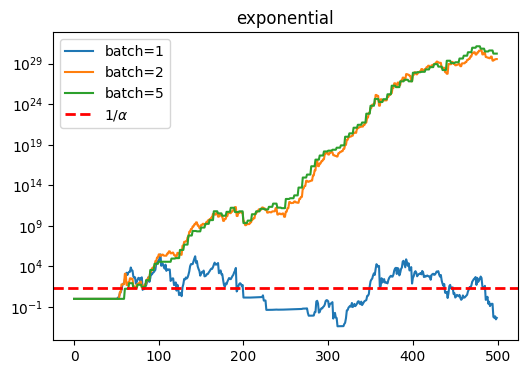

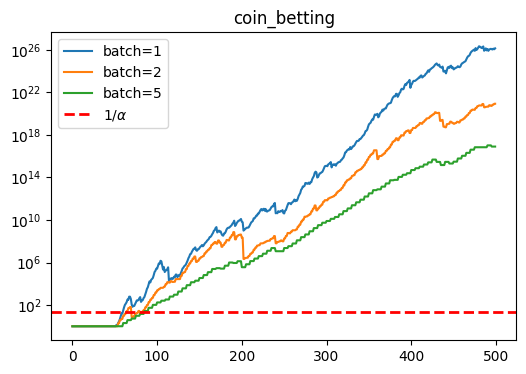

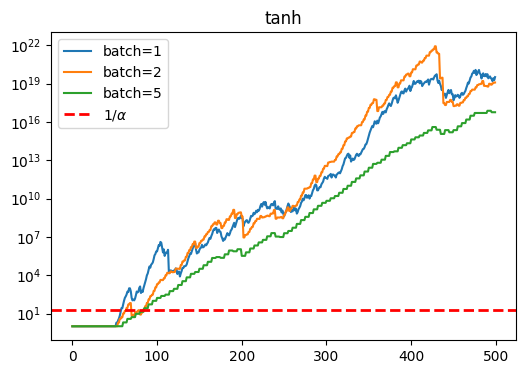

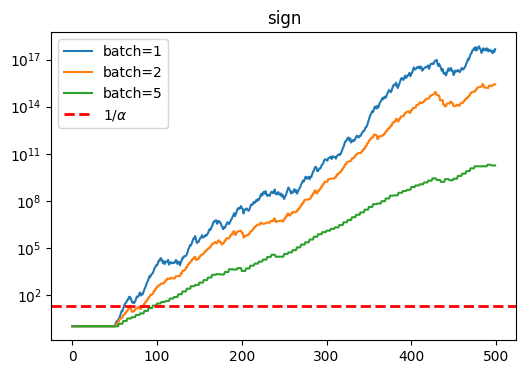

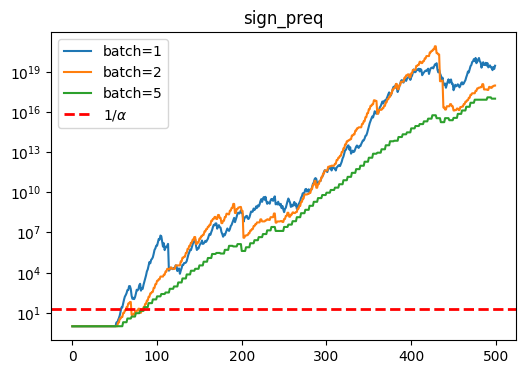

In [76]:
import matplotlib.pyplot as plt
alpha = 0.05
for strategy_name in betting_strategies.keys():
    plt.figure(figsize=(6, 4))
    for b in batch_list:
        plt.plot(
            martingales[strategy_name][b][j, :],
            label=f"batch={b}"
        )
    plt.yscale("log")
    plt.title(strategy_name)
    plt.axhline(
        y=1/alpha,
        color="red",
        linestyle="--",
        linewidth=2,
        label=r"$1/\alpha$"
    )
    plt.legend()
    plt.show()

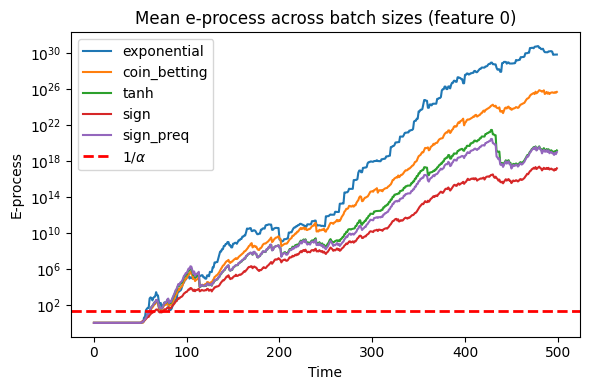

In [77]:
plt.figure(figsize=(6, 4))

j = 0

for strategy_name in betting_strategies.keys():
    mean_process = np.mean(
        [martingales[strategy_name][b][j, :] for b in batch_list],
        axis=0
    )

    plt.plot(mean_process, label=strategy_name)

plt.axhline(
    y=1 / alpha,
    color="red",
    linestyle="--",
    linewidth=2,
    label=r"$1/\alpha$"
)

plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("E-process")
plt.title(f"Mean e-process across batch sizes (feature {j})")
plt.legend()
plt.tight_layout()
plt.show()

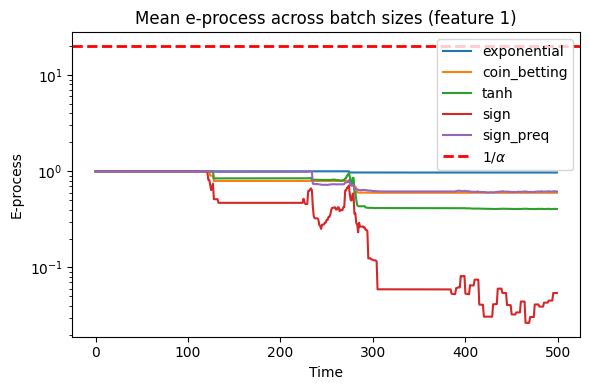

In [78]:
plt.figure(figsize=(6, 4))

j = 1

for strategy_name in betting_strategies.keys():
    mean_process = np.mean(
        [martingales[strategy_name][b][j, :] for b in batch_list],
        axis=0
    )

    plt.plot(mean_process, label=strategy_name)

plt.axhline(
    y=1 / alpha,
    color="red",
    linestyle="--",
    linewidth=2,
    label=r"$1/\alpha$"
)

plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("E-process")
plt.title(f"Mean e-process across batch sizes (feature {j})")
plt.legend()
plt.tight_layout()
plt.show()

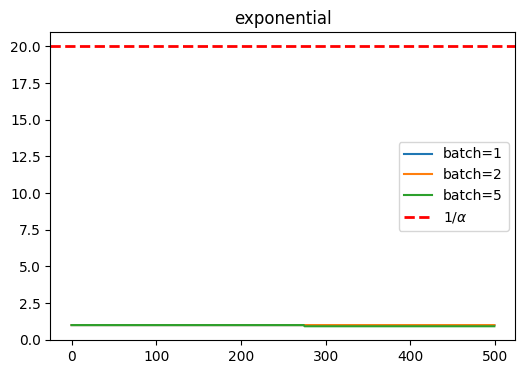

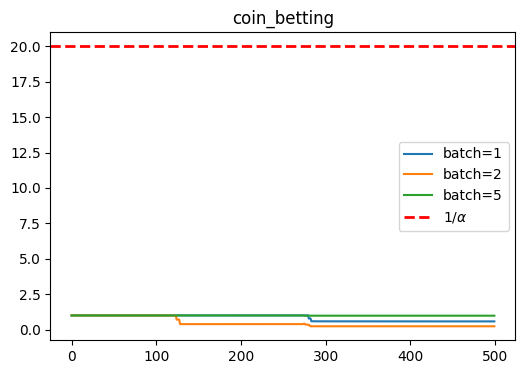

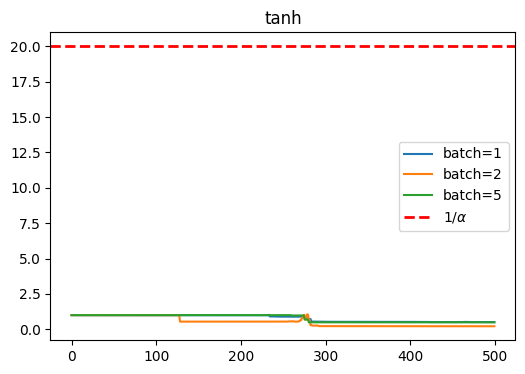

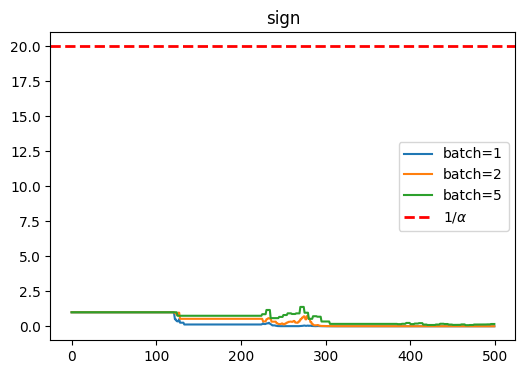

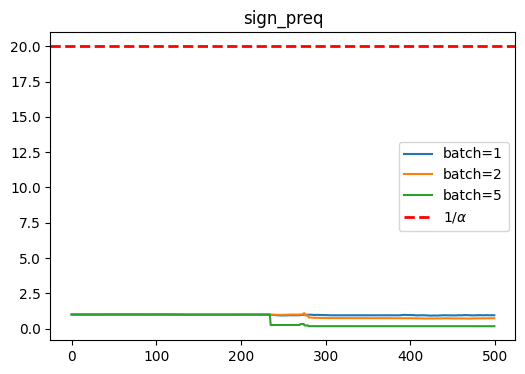

In [79]:
import matplotlib.pyplot as plt
alpha = 0.05
j = 1
for strategy_name in betting_strategies.keys():
    plt.figure(figsize=(6, 4))
    for b in batch_list:
        plt.plot(
            martingales[strategy_name][b][j, :],
            label=f"batch={b}"
        )
    #plt.yscale("log")
    plt.title(strategy_name)
    plt.axhline(
        y=1/alpha,
        color="red",
        linestyle="--",
        linewidth=2,
        label=r"$1/\alpha$"
    )
    plt.legend()
    plt.show()

### Misspecified setting

In [133]:
X, Y, Sigma, j = generate_data_noise(n=500, beta_strength=1, noise = 1.5)

In [134]:
from ML_e_process import ML_e_process
from sklearn.linear_model import LassoCV

from ExponentialBet import ExponentialBet  
from AntisymmetricBet import AntisymmetricBet  # adjust import
from utils import prepare_exponential_parameters, prepare_coin_betting_parameters, g_family_cb, update_g_func_static, prepare_lambda_parameters, g_family_tanh, g_family_sign


etas = prepare_exponential_parameters(0.01, 5, 50)
strategy_exp = ExponentialBet(
    parameters=etas,
    exact=True
)



params_cb = prepare_coin_betting_parameters(lam_start = 0.01, lam_end = 0.99, lam_num = 50, M_start = 0.01, M_end = 5, M_num = 50)
strategy_cb = AntisymmetricBet(
    g_family= g_family_cb, 
    update_g_func = update_g_func_static, 
    parameters=params_cb,
)


params_tanh = prepare_lambda_parameters(lam_start = 0.01, lam_end = 0.99, lam_num = 50)
strategy_tanh = AntisymmetricBet(
    g_family= g_family_tanh, 
    update_g_func = update_g_func_static, 
    parameters=params_tanh,
    prequential=True,
)

params_sign = prepare_lambda_parameters(lam_start = 0.01, lam_end = 0.99, lam_num = 50)

strategy_sign = AntisymmetricBet(
    g_family= g_family_sign, 
    update_g_func = update_g_func_static, 
    parameters=params_sign,
    prequential=False,
)

strategy_sign_preq = AntisymmetricBet(
    g_family= g_family_sign, 
    update_g_func = update_g_func_static, 
    parameters=params_sign,
    prequential=True,
)


betting_strategies = {
    "exponential": strategy_exp,
    "coin_betting": strategy_cb,
    "tanh": strategy_tanh,
    "sign": strategy_sign,
    "sign_preq": strategy_sign_preq,

}

batch_list = [1, 2, 5]
e_process = ML_e_process(batch_list=batch_list, n_init=50, b_resamplings=20, study_j=[0, 1],
                 betting_strategies=betting_strategies, model=LassoCV(),
                 #learn_conditional_distribution=get_data_statistics,
                 samplers=None, #sampling_args={}
                 learn_conditional_distribution=True,
                 optional_stopping=True, 
                 )


In [135]:
martingales = e_process.martingales(X, y=Y)

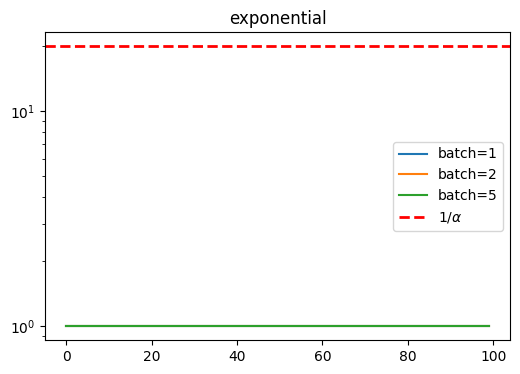

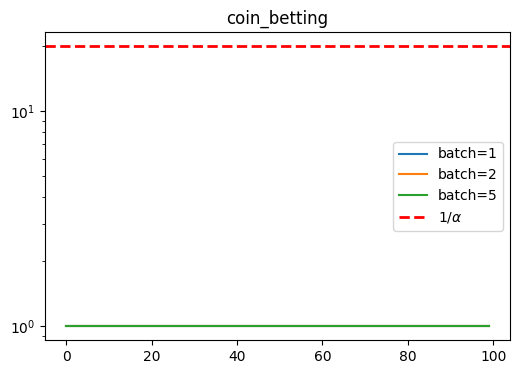

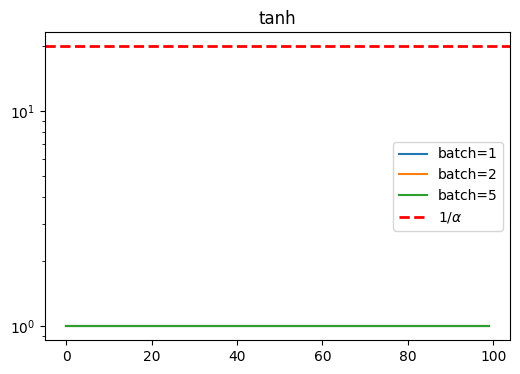

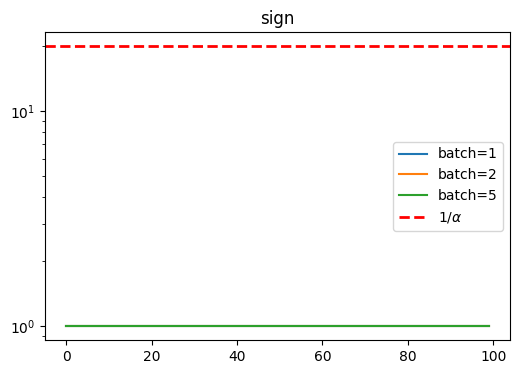

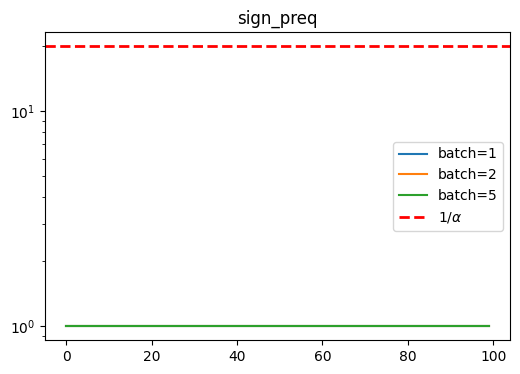

In [ ]:
import matplotlib.pyplot as plt
alpha = 0.05
for strategy_name in betting_strategies.keys():
    plt.figure(figsize=(6, 4))
    for b in batch_list:
        plt.plot(
            martingales[strategy_name][b][j, :],
            label=f"batch={b}"
        )
    plt.yscale("log")
    plt.title(strategy_name)
    plt.axhline(
        y=1/alpha,
        color="red",
        linestyle="--",
        linewidth=2,
        label=r"$1/\alpha$"
    )
    plt.legend()
    plt.show()

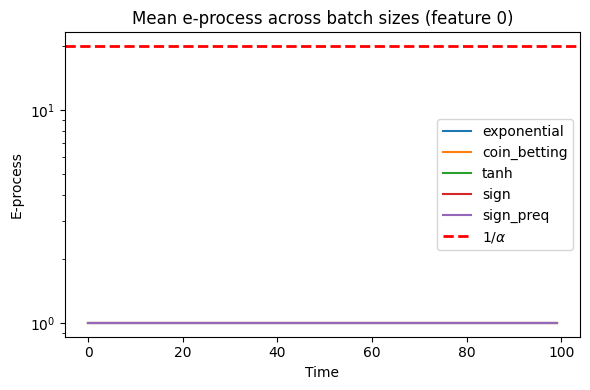

In [ ]:
plt.figure(figsize=(6, 4))

j = 0

for strategy_name in betting_strategies.keys():
    mean_process = np.mean(
        [martingales[strategy_name][b][j, :] for b in batch_list],
        axis=0
    )

    plt.plot(mean_process, label=strategy_name)

plt.axhline(
    y=1 / alpha,
    color="red",
    linestyle="--",
    linewidth=2,
    label=r"$1/\alpha$"
)

plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("E-process")
plt.title(f"Mean e-process across batch sizes (feature {j})")
plt.legend()
plt.tight_layout()
plt.show()

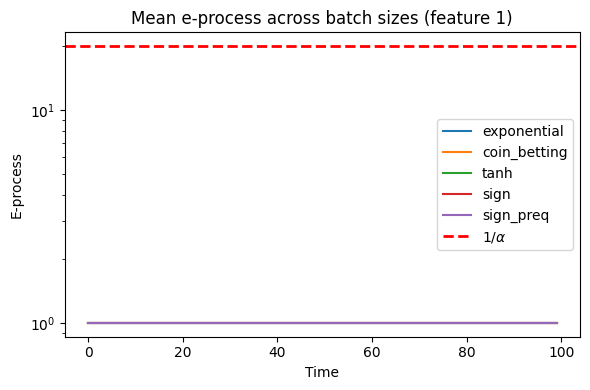

In [ ]:
plt.figure(figsize=(6, 4))

j = 1

for strategy_name in betting_strategies.keys():
    mean_process = np.mean(
        [martingales[strategy_name][b][j, :] for b in batch_list],
        axis=0
    )

    plt.plot(mean_process, label=strategy_name)

plt.axhline(
    y=1 / alpha,
    color="red",
    linestyle="--",
    linewidth=2,
    label=r"$1/\alpha$"
)

plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("E-process")
plt.title(f"Mean e-process across batch sizes (feature {j})")
plt.legend()
plt.tight_layout()
plt.show()